In [260]:
%pip install openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [261]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import mne

In [262]:

# Your bipolar_pairs list
bipolar_pairs = [
    ('EEG Fp1-REF', 'EEG F7-REF'),
    ('EEG F7-REF',  'EEG T3-REF'),
    ('EEG T3-REF',  'EEG T5-REF'),
    ('EEG T5-REF',  'EEG O1-REF'),
    ('EEG Fp1-REF', 'EEG F3-REF'),
    ('EEG F3-REF',  'EEG C3-REF'),
    ('EEG C3-REF',  'EEG P3-REF'),
    ('EEG P3-REF',  'EEG O1-REF'),
    ('EEG Fz-REF',  'EEG Cz-REF'),
    ('EEG Cz-REF',  'EEG Pz-REF'),
    ('EEG Fp2-REF', 'EEG F4-REF'),
    ('EEG F4-REF',  'EEG C4-REF'),
    ('EEG C4-REF',  'EEG P4-REF'),
    ('EEG P4-REF',  'EEG O2-REF'),
    ('EEG Fp2-REF', 'EEG F8-REF'),
    ('EEG F8-REF',  'EEG T4-REF'),
    ('EEG T4-REF',  'EEG T6-REF'),
    ('EEG T6-REF',  'EEG O2-REF'),
]

desired_order = [
    'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2',
    'Fp1-F7', 'F7-T3', 'T3-T5', 'T5-O1',
    'Fz-Cz', 'Cz-Pz',
]

def pair_name(pair):
    # Extract labels removing 'EEG ' and '-REF'
    left = pair[0].replace('EEG ', '').replace('-REF', '')
    right = pair[1].replace('EEG ', '').replace('-REF', '')
    return f"{left}-{right}"

# Create a dict from name to pair for quick lookup
name_to_pair = {pair_name(p): p for p in bipolar_pairs}

# Reorder bipolar_pairs according to desired_order
reordered_pairs = [name_to_pair[name] for name in desired_order]

# Let's print to verify
for name, pair in zip(desired_order, reordered_pairs):
    print(f"{name}: {pair}")

bipolar_pairs = [
    ('EEG Fp1-REF', 'EEG F7-REF'),
    ('EEG F7-REF',  'EEG T3-REF'),
    ('EEG T3-REF',  'EEG T5-REF'),
    ('EEG T5-REF',  'EEG O1-REF'),
    ('EEG Fp1-REF', 'EEG F3-REF'),
    ('EEG F3-REF',  'EEG C3-REF'),
    ('EEG C3-REF',  'EEG P3-REF'),
    ('EEG P3-REF',  'EEG O1-REF'),
    ('EEG Fz-REF',  'EEG Cz-REF'),
    ('EEG Cz-REF',  'EEG Pz-REF'),
    ('EEG Fp2-REF', 'EEG F4-REF'),
    ('EEG F4-REF',  'EEG C4-REF'),
    ('EEG C4-REF',  'EEG P4-REF'),
    ('EEG P4-REF',  'EEG O2-REF'),
    ('EEG Fp2-REF', 'EEG F8-REF'),
    ('EEG F8-REF',  'EEG T4-REF'),
    ('EEG T4-REF',  'EEG T6-REF'),
    ('EEG T6-REF',  'EEG O2-REF'),
]

def normalize_channel(ch):
    return ch.strip().upper()

bipolar_pairs = [(normalize_channel(a), normalize_channel(b)) for a, b in bipolar_pairs]

def make_ch_names(pairs):
    def pretty(ch):
        return ch.replace('EEG ', '').replace('-REF', '').capitalize()
    return [f"{pretty(a)}-{pretty(b)}" for a, b in pairs]

anode = [a for a, _ in bipolar_pairs]
cathode = [b for _, b in bipolar_pairs]
ch_names = make_ch_names(reordered_pairs)



def getArray(filename: str):
    raw = mne.io.read_raw_edf(filename, preload=True)
    raw.rename_channels(lambda ch: ch.upper())
    drop_candidates = ['ECG EKG', 'RESP EFFORT','ECG EKG-REF','RESP EFFORT-REF']
    available = set(raw.ch_names)
    to_drop = [ch for ch in drop_candidates if ch in available]
    if to_drop:
        raw.drop_channels(to_drop)
    raw = mne.set_bipolar_reference(raw, anode=anode, cathode=cathode, ch_name=ch_names, copy=True)
    array = raw.get_data()
    # raw.plot()
    return array

Fp2-F4: ('EEG Fp2-REF', 'EEG F4-REF')
F4-C4: ('EEG F4-REF', 'EEG C4-REF')
C4-P4: ('EEG C4-REF', 'EEG P4-REF')
P4-O2: ('EEG P4-REF', 'EEG O2-REF')
Fp1-F3: ('EEG Fp1-REF', 'EEG F3-REF')
F3-C3: ('EEG F3-REF', 'EEG C3-REF')
C3-P3: ('EEG C3-REF', 'EEG P3-REF')
P3-O1: ('EEG P3-REF', 'EEG O1-REF')
Fp2-F8: ('EEG Fp2-REF', 'EEG F8-REF')
F8-T4: ('EEG F8-REF', 'EEG T4-REF')
T4-T6: ('EEG T4-REF', 'EEG T6-REF')
T6-O2: ('EEG T6-REF', 'EEG O2-REF')
Fp1-F7: ('EEG Fp1-REF', 'EEG F7-REF')
F7-T3: ('EEG F7-REF', 'EEG T3-REF')
T3-T5: ('EEG T3-REF', 'EEG T5-REF')
T5-O1: ('EEG T5-REF', 'EEG O1-REF')
Fz-Cz: ('EEG Fz-REF', 'EEG Cz-REF')
Cz-Pz: ('EEG Cz-REF', 'EEG Pz-REF')


In [263]:
annotations = pd.read_excel('C:/bt23ece064/dataset/annot.xlsx')

In [264]:

import os

eeg_set = []
for i in range(1, 80):
    filepath = f'C:/bt23ece064/dataset/eeg{i}.edf'
    if os.path.exists(filepath):
        try:
            eeg = getArray(filepath)
            eeg_set.append(eeg)
        except ValueError as e:
            print(f"Error in file: {filepath}")
            print(e)
     

Extracting EDF parameters from C:\bt23ece064\dataset\eeg67.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1254399  =      0.000 ...  4899.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_17412\1656997136.py:85: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17412\1656997136.py:85: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=1254400
    Range : 0 ... 1254399 =      0.000 ...  4899.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg68.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 925439  =      0.000 ...  3614.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_17412\1656997136.py:85: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17412\1656997136.py:85: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=925440
    Range : 0 ... 925439 =      0.000 ...  3614.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg69.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1017087  =      0.000 ...  3972.996 secs...


...

EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=1073408
    Range : 0 ... 1073407 =      0.000 ...  4192.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg78.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1272575  =      0.000 ...  4970.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_17412\1656997136.py:85: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17412\1656997136.py:85: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=1272576
    Range : 0 ... 1272575 =      0.000 ...  4970.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg79.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 844031  =      0.000 ...  3296.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_17412\1656997136.py:85: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17412\1656997136.py:85: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=844032
    Range : 0 ... 844031 =      0.000 ...  3296.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz


In [265]:
import pywt
import pandas as pd
import numpy as np

# List to store all extracted feature dictionaries
feature_list = []

# Define wavelet and decomposition level
wavelet = 'db2'
levels = 3  # for a3 and d1, d2, d3

# Loop over all annotations
for i in range(len(annotations)):
    patient_id = int(annotations['FILE ID'].iloc[i])
    start = int(annotations['Start'].iloc[i] * 256)
    stop = int(annotations['Stop'].iloc[i] * 256)
    
    print(f"Processing annotation {i+1}/{len(annotations)} - Patient {patient_id}, Time: {annotations['Start'].iloc[i]:.1f}s-{annotations['Stop'].iloc[i]:.1f}s")
    
    for ch_idx, col in enumerate(channel_cols):
        if ch_idx >= len(eeg_set[patient_id - 1]):
            continue
        
        segment = eeg_set[patient_id - 1][ch_idx][start:stop]
        
        # Check if this channel is seizure or non-seizure based on annotation
        label = 1 if annotations[col].iloc[i] == 1 else 0
        
        # Skip empty segments if needed
        if len(segment) == 0:
            continue
        
        # Perform 3-level DWT decomposition (a3, d1, d2, d3)
        coeffs = pywt.wavedec(segment, wavelet, level=levels)
        # coeffs = [a3, d3, d2, d1] (pywt returns approximation coeff first)
        a3 = coeffs[0]
        d3 = coeffs[1]
        d2 = coeffs[2]
        d1 = coeffs[3]
        
        # Extract statistics for each coeff array
        def extract_stats(arr):
            return {
                'max': np.max(arr),
                'min': np.min(arr),
                'mean': np.mean(arr),
                'std': np.std(arr)
            }
        
        features = {}
        features['patient_id'] = patient_id
        features['channel'] = col
        features['label'] = label
        
        # Wavelet stats by sub-band
        for band_name, data in zip(['a3', 'd1', 'd2', 'd3'], [a3, d1, d2, d3]):
            stats = extract_stats(data)
            for stat_name, value in stats.items():
                features[f'{band_name}_{stat_name}'] = value
        
        feature_list.append(features)

# Create DataFrame
features_df = pd.DataFrame(feature_list)

print(features_df.head())


ValueError: cannot convert float NaN to integer

array([ 1,  4,  5,  7,  9, 11, 13, 14, 15, 16, 17, 19, 20, 21, 22, 25, 31,
       34, 36, 38, 39, 40, 41, 44, 47, 50, 51, 52, 62, 63, 66, 67, 69, 73,
       75, 76, 77, 78, 79])

In [ ]:
annotations = annotations.sort_values(by=['FILE ID','Start'], ascending=[True,True])
annotations = annotations.dropna(axis=0)
     
     

import numpy as np


seizured_segments = [
    [np.zeros_like(channel, dtype=float) for channel in patient_eeg] 
    for patient_eeg in eeg_set
]
non_seizured_segments = [
    [np.zeros_like(channel, dtype=float) for channel in patient_eeg] 
    for patient_eeg in eeg_set
]


unordered_seizured_segments = []
unordered_non_seizured_segments = []

channel_cols = ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'Fp1-F3', 'F3-C3', 'C3-P3',
                'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2', 'Fp1-F7', 'F7-T3', 'T3-T5', 
                'T5-O1', 'Fz-Cz', 'Cz-Pz']

print(f"Starting processing {len(annotations)} annotations...")
print(f"Total patients in eeg_set: {len(eeg_set)}")


for i in range(len(annotations)):
    patient = int(annotations['FILE ID'].iloc[i] - 1)
    start = int(annotations['Start'].iloc[i] * 256) 
    stop = int(annotations['Stop'].iloc[i] * 256)
    
    
    print(f"Processing annotation {i+1}/{len(annotations)} - Patient {patient+1}, Time: {annotations['Start'].iloc[i]:.1f}s-{annotations['Stop'].iloc[i]:.1f}s")
    
    seizure_count = 0
    non_seizure_count = 0
    
    for ch_idx, col in enumerate(channel_cols):
        if ch_idx < len(eeg_set[patient]): 
            if annotations[col].iloc[i] == 1: 
                seizured_segments[patient][ch_idx][start:stop] = eeg_set[patient][ch_idx][start:stop]
                non_seizured_segments[patient][ch_idx][start:stop] = 0
                unordered_seizured_segments.append(eeg_set[patient][ch_idx][start:stop])
                seizure_count += 1
            else:  
                seizured_segments[patient][ch_idx][start:stop] = 0
                non_seizured_segments[patient][ch_idx][start:stop] = eeg_set[patient][ch_idx][start:stop]
                unordered_non_seizured_segments.append(eeg_set[patient][ch_idx][start:stop])
                non_seizure_count += 1
    
    print(f"  Annotation {i+1}: {seizure_count} seizure channels, {non_seizure_count} non-seizure channels")

print("\nProcessing complete!")
print(f"Total annotations processed: {len(annotations)}")

[[array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.])],
 [array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),
  array([0., 0., 0., ..., 0., 0., 0.]),

In [ ]:
%pip install PyWavelets


     ---------------------------------------- 4.2/4.2 MB 20.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


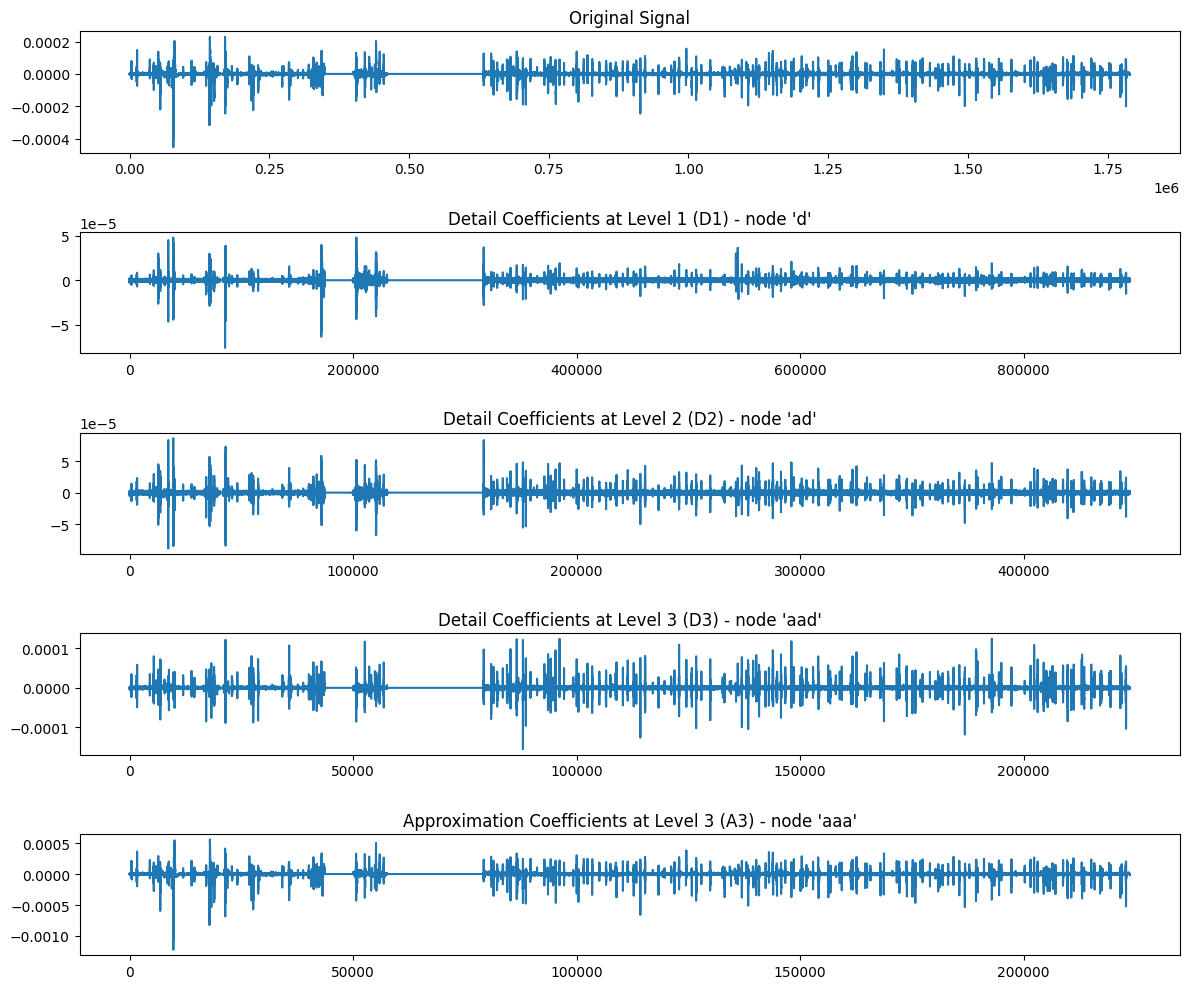

In [ ]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
signal = eeg_set[0][0]
wp = pywt.WaveletPacket(data=signal, wavelet='haar', maxlevel=3)

# Extract nodes for D1, D2, D3, and A3
D1 = wp['d']     # detail at level 1
D2 = wp['ad']    # detail at level 2
D3 = wp['aad']   # detail at level 3
A3 = wp['aaa']   # approximation at level 3

# Plot original signal and extracted coefficients
plt.figure(figsize=(12, 10))

plt.subplot(5,1,1)
plt.title("Original Signal")
plt.plot(signal)

plt.subplot(5,1,2)
plt.title("Detail Coefficients at Level 1 (D1) - node 'd'")
plt.plot(D1.data)

plt.subplot(5,1,3)
plt.title("Detail Coefficients at Level 2 (D2) - node 'ad'")
plt.plot(D2.data)

plt.subplot(5,1,4)
plt.title("Detail Coefficients at Level 3 (D3) - node 'aad'")
plt.plot(D3.data)

plt.subplot(5,1,5)
plt.title("Approximation Coefficients at Level 3 (A3) - node 'aaa'")
plt.plot(A3.data)

plt.tight_layout()
plt.show()

array([7.17162525e-06, 7.01903748e-06, 6.86644971e-06, ...,
       6.10351085e-06, 4.88280868e-06, 3.81469428e-06])

In [ ]:
import pywt
import pandas as pd
import numpy as np
import random
import pywt  # Make sure you import pywt

# Define wavelet and level
wavelet = 'haar'
level = 4

# EEG indices and train-test split
eeg_idx = [1, 4, 5, 7, 9, 11, 13, 14, 15, 16, 17, 19, 20, 21, 22, 25, 31, 34,
           36, 38, 39, 40, 41, 44, 47, 50, 51, 52, 62, 63, 66, 67, 69, 73, 75,
           76, 77, 78, 79]

random.seed(42)
train_idx = random.sample(eeg_idx, int(len(eeg_idx) * 0.75))
test_idx = [i for i in eeg_idx if i not in train_idx]

def extract_stats(arr):
    return {
        'max': np.max(arr),
        'min': np.min(arr),
        'mean': np.mean(arr),
        'std': np.std(arr)
    }

def extract_features_for_indices(indices):
    feature_list = []
    for i in range(len(annotations)):
        patient_id = int(annotations['FILE ID'].iloc[i])
        
        if patient_id not in indices:
            continue
        
        start = int(annotations['Start'].iloc[i] * 256)
        stop = int(annotations['Stop'].iloc[i] * 256)
        
        print(f"Processing annotation {i+1}/{len(annotations)} - Patient {patient_id}, Time: {annotations['Start'].iloc[i]:.1f}s-{annotations['Stop'].iloc[i]:.1f}s")
        
        for ch_idx, col in enumerate(channel_cols):
            if ch_idx >= len(eeg_set[patient_id - 1]):
                continue
            
            segment = eeg_set[patient_id - 1][ch_idx][start:stop]
            label = 1 if annotations[col].iloc[i] == 1 else 0
            
            if len(segment) == 0:
                continue
            
            # Apply DWT
            coeffs = pywt.wavedec(segment, wavelet=wavelet, level=level)
            # coeffs = [A4, D4, D3, D2, D1]
            A4, D4, D3, D2, D1 = coeffs

            features = {'label': label}
            
            # Extract stats from each coefficient set
            for name, coeff in zip(['A4', 'D4', 'D3', 'D2', 'D1'], [A4, D4, D3, D2, D1]):
                stats = extract_stats(coeff)
                for stat_name, value in stats.items():
                    features[f'{name}_{stat_name}'] = value

            feature_list.append(features)
    
    return pd.DataFrame(feature_list)

# Extract features for training and testing
train_df = extract_features_for_indices(train_idx)
test_df = extract_features_for_indices(test_idx)

# features = ['slope_alpha', 'intercept_alpha', 'midband_alpha','slope_beta', 'intercept_beta', 'midband_beta','slope_gamma', 'intercept_gamma', 'midband_gamma','slope_delta', 'intercept_delta', 'midband_delta','label']
# train_frames = []
# test_frames = []
# for i in train_idx:
#     print(f'[TRAIN] Processing file {i}')
#     sfilename = f'C:/bt23ece064/features/eeg{i}_seizure_features.csv'
#     nsfilename = f'C:/bt23ece064/features/eeg{i}_non_seizure_features.csv'

#     sdf = pd.read_csv(sfilename)
#     nsdf = pd.read_csv(nsfilename)
#     sdf['label'] = 1
#     nsdf['label'] = 0

#     train_frames.append(sdf[features])
#     train_frames.append(nsdf[features])

# train_df1 = pd.concat(train_frames, ignore_index=True)

# for i in test_idx:
#     print(f'[TEST] Processing file {i}')
#     sfilename = f'C:/bt23ece064/features/eeg{i}_seizure_features.csv'
#     nsfilename = f'C:/bt23ece064/features/eeg{i}_non_seizure_features.csv'

#     sdf = pd.read_csv(sfilename)
#     nsdf = pd.read_csv(nsfilename)
#     sdf['label'] = 1
#     nsdf['label'] = 0

#     test_frames.append(sdf[features])
#     test_frames.append(nsdf[features])

# test_df1 = pd.concat(test_frames, ignore_index=True)
# print("Training set sample:")
# print(train_df.head())

# print("\nTesting set sample:")
# print(test_df.head())

# train_df = pd.concat([train_df, train_df1], ignore_index=True)

Processing annotation 1/364 - Patient 1, Time: 104.0s-122.0s
Processing annotation 2/364 - Patient 1, Time: 349.0s-428.0s
Processing annotation 3/364 - Patient 1, Time: 760.0s-779.0s
Processing annotation 4/364 - Patient 1, Time: 956.0s-965.0s
Processing annotation 5/364 - Patient 1, Time: 973.0s-982.0s
Processing annotation 6/364 - Patient 1, Time: 1179.0s-1195.0s
Processing annotation 7/364 - Patient 1, Time: 1601.0s-1613.0s
Processing annotation 8/364 - Patient 1, Time: 1622.0s-1632.0s
Processing annotation 9/364 - Patient 1, Time: 2850.0s-2860.0s
Processing annotation 10/364 - Patient 1, Time: 3023.0s-3033.0s
Processing annotation 11/364 - Patient 1, Time: 3074.0s-3095.0s
Processing annotation 12/364 - Patient 1, Time: 3258.0s-3272.0s
Processing annotation 13/364 - Patient 1, Time: 3854.0s-3867.0s
Processing annotation 14/364 - Patient 1, Time: 4025.0s-4039.0s
Processing annotation 15/364 - Patient 1, Time: 4066.0s-4086.0s
Processing annotation 16/364 - Patient 1, Time: 4430.0s-449

In [ ]:
train_df

,label,A4_max,A4_min,A4_mean,A4_std,D4_max,D4_min,D4_mean,D4_std,D3_max,...,D3_mean,D3_std,D2_max,D2_min,D2_mean,D2_std,D1_max,D1_min,D1_mean,D1_std
0,0,0.000020,-0.000017,1.064141e-06,0.000008,0.000007,-0.000006,9.112881e-08,0.000002,0.000004,...,-5.806895e-09,0.000001,0.000003,-0.000004,1.589456e-08,1.083417e-06,0.000002,-1.618438e-06,-1.311234e-09,5.787351e-07
1,0,0.000015,-0.000014,6.091590e-07,0.000006,0.000010,-0.000008,-3.298121e-08,0.000002,0.000006,...,-2.706762e-08,0.000001,0.000003,-0.000003,-8.145962e-09,6.132411e-07,0.000001,-9.710626e-07,-9.834257e-10,3.103374e-07
2,0,0.000020,-0.000021,1.043345e-06,0.000007,0.000006,-0.000007,-1.364283e-08,0.000002,0.000005,...,1.404894e-09,0.000001,0.000004,-0.000003,-1.655683e-09,7.201988e-07,0.000002,-1.618438e-06,-4.214682e-10,3.488627e-07
3,0,0.000030,-0.000023,-2.247756e-06,0.000009,0.000007,-0.000010,-1.483492e-08,0.000002,0.000004,...,-2.922179e-08,0.000001,0.000005,-0.000004,-2.251729e-09,1.199168e-06,0.000002,-1.942125e-06,1.685873e-09,6.057451e-07
4,0,0.000024,-0.000018,1.926950e-06,0.000008,0.000006,-0.000005,8.265171e-08,0.000002,0.000004,...,-3.821311e-08,0.000001,0.000004,-0.000004,7.947280e-10,1.406193e-06,0.000002,-2.157917e-06,-7.492767e-10,7.648302e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4024,0,0.000210,-0.000145,-2.209901e-06,0.000056,0.000074,-0.000073,3.186687e-07,0.000015,0.000038,...,3.839284e-08,0.000006,0.000019,-0.000020,-2.131608e-08,2.570090e-06,0.000007,-7.808251e-06,3.602292e-09,1.010194e-06
4025,0,0.000293,-0.000242,7.471354e-07,0.000078,0.000053,-0.000105,4.759251e-08,0.000014,0.000028,...,8.759256e-08,0.000006,0.000014,-0.000016,5.027378e-08,2.959999e-06,0.000010,-1.088423e-05,-2.132936e-09,1.622733e-06
4026,0,0.001297,-0.001497,-5.799979e-05,0.000657,0.000063,-0.000104,-6.441747e-08,0.000017,0.000035,...,-2.343859e-07,0.000009,0.000058,-0.000039,1.960677e-08,7.288281e-06,0.000035,-4.270877e-05,-3.628361e-08,5.874736e-06
4027,1,0.000203,-0.000307,-2.256555e-06,0.000098,0.000064,-0.000042,-4.050056e-07,0.000011,0.000033,...,-6.095457e-08,0.000007,0.000030,-0.000047,-5.677585e-08,5.697975e-06,0.000035,-4.401014e-05,-1.502535e-08,4.924884e-06


,label,A4_max,A4_min,A4_mean,A4_std,D4_max,D4_min,D4_mean,D4_std,D3_max,...,midband_alpha,slope_beta,intercept_beta,midband_beta,slope_gamma,intercept_gamma,midband_gamma,slope_delta,intercept_delta,midband_delta


In [322]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import numpy as np
from collections import Counter

# Assuming train_df and test_df are already loaded

features = train_df.columns[1:]

# Replace inf with NaN and impute median in train
train_df[features] = train_df[features].replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy='median')
train_df[features] = imputer.fit_transform(train_df[features])

# Replace inf with NaN and impute median in test
test_df[features] = test_df[features].replace([np.inf, -np.inf], np.nan)
test_df[features] = imputer.transform(test_df[features])

# Extract features and labels
X_train = train_df[features].astype('float32').values
X_test = test_df[features].astype('float32').values

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['label'])
y_test = label_encoder.transform(test_df['label'])

# Log transform and scale features
# X_train = np.log1p(X_train)
# X_test = np.log1p(X_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to balance classes in training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = X_train_scaled, y_train


# Compute class weights (optional after SMOTE, but usually less needed)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_resampled), y=y_train_resampled)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(f"Class weights {class_weights_tensor}")

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_resampled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Now you can create DataLoader, define your model, loss, and optimizer
# Example for DataLoader:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# You’re ready to build and train your model!


Class weights tensor([0.6031, 2.9238])


In [301]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EEGDataset(X_train_scaled, y_train)
test_dataset = EEGDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [302]:
class_weights_tensor

tensor([0.6031, 2.9238])

In [303]:
import torch
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(NeuralNet, self).__init__()
        self.net = nn.Sequential(
      
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.BatchNorm1d(64),
        nn.Dropout(0.2),
        
       
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.BatchNorm1d(32),
        nn.Dropout(0.3),
        
       
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.BatchNorm1d(16),
        nn.Dropout(0.2),
        
     
        nn.Linear(16, 1)
    )
    def forward(self, x):
        return self.net(x)

# Example usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralNet(X_train_scaled.shape[1]).to(device)


In [305]:
pos_weight = torch.tensor([2.9238/0.6031]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-7)

In [317]:
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
import numpy as np

# Assuming these are defined elsewhere in your code
# model, criterion, optimizer, scheduler, train_loader, test_loader, device, threshold

threshold = 0.52  # Your threshold
best_test_loss = float('inf')
patience = 20
epochs_no_improve = 0
history = {
    'loss': [], 'test_loss': [], 'accuracy': [], 'test_accuracy': [], 'test_auc': []
}

for epoch in range(1, 501):
    # === TRAINING PHASE ===
    model.train()
    train_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.view(-1, 1).float().to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

        # Training accuracy calculation
        with torch.no_grad():  # No gradients needed for accuracy calculation
            preds = (torch.sigmoid(outputs) > threshold).float()  # Keep as float for consistency
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    avg_train_loss = train_loss / total
    train_acc = correct / total

    # === EVALUATION PHASE ===
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch_float = y_batch.view(-1, 1).float().to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch_float)
            test_loss += loss.item() * X_batch.size(0)

            # Get probabilities and store for AUC calculation
            probs = torch.sigmoid(outputs).squeeze()
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

            # Test accuracy calculation
            preds = (probs > threshold).float()
            test_correct += (preds.cpu() == y_batch_float.squeeze().cpu()).sum().item()
            test_total += y_batch.size(0)

    avg_test_loss = test_loss / test_total
    test_acc = test_correct / test_total

    # Calculate AUC with better error handling
    try:
        # Check if we have both classes in the test set
        unique_targets = np.unique(all_targets)
        if len(unique_targets) > 1:
            test_auc = roc_auc_score(all_targets, all_probs)
        else:
            print(f"Warning: Only one class present in test set at epoch {epoch}")
            test_auc = float('nan')
    except ValueError as e:
        print(f"Warning: Could not calculate AUC at epoch {epoch}: {e}")
        test_auc = float('nan')

    # Update learning rate scheduler
    scheduler.step(avg_test_loss)

    # Print progress
    print(f"Epoch {epoch:03d}: "
          f"Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Test Loss={avg_test_loss:.4f}, Test Acc={test_acc:.4f}, Test AUC={test_auc:.4f}")

    # Store history
    history['loss'].append(avg_train_loss)
    history['test_loss'].append(avg_test_loss)
    history['accuracy'].append(train_acc)
    history['test_accuracy'].append(test_acc)
    history['test_auc'].append(test_auc)

    # Early stopping based on test loss
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        torch.save(model.state_dict(), "best_model.pt")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

# Load best model
model.load_state_dict(torch.load("best_model.pt"))
print("Best model loaded.")


Epoch 001: Train Loss=1.0737, Train Acc=0.6701, Test Loss=1.1037, Test Acc=0.7572, Test AUC=0.5147
Epoch 002: Train Loss=1.0872, Train Acc=0.6679, Test Loss=1.1033, Test Acc=0.7628, Test AUC=0.5120
Epoch 003: Train Loss=1.0711, Train Acc=0.6796, Test Loss=1.1063, Test Acc=0.7624, Test AUC=0.5162
Epoch 004: Train Loss=1.0726, Train Acc=0.6721, Test Loss=1.1083, Test Acc=0.7320, Test AUC=0.5148
Epoch 005: Train Loss=1.0827, Train Acc=0.6664, Test Loss=1.1010, Test Acc=0.7708, Test AUC=0.5203
Epoch 006: Train Loss=1.0744, Train Acc=0.6684, Test Loss=1.1119, Test Acc=0.7157, Test AUC=0.5178
Epoch 007: Train Loss=1.0879, Train Acc=0.6652, Test Loss=1.1094, Test Acc=0.7236, Test AUC=0.5128
Epoch 008: Train Loss=1.0749, Train Acc=0.6659, Test Loss=1.1076, Test Acc=0.7316, Test AUC=0.5122
Epoch 009: Train Loss=1.0863, Train Acc=0.6548, Test Loss=1.1087, Test Acc=0.7297, Test AUC=0.5134
Epoch 010: Train Loss=1.0900, Train Acc=0.6704, Test Loss=1.1065, Test Acc=0.7451, Test AUC=0.5202
Epoch 011:

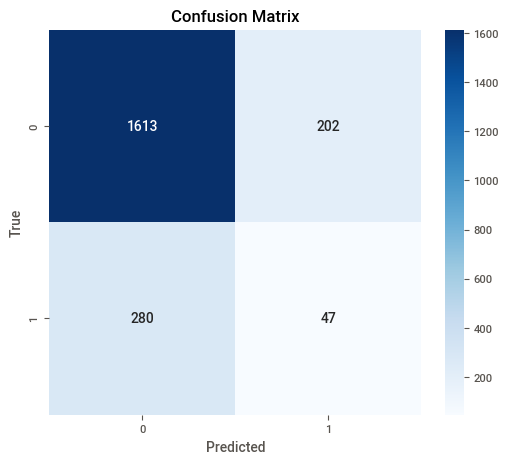

Precision: 0.1888
Recall:    0.1437
F1-score:  0.1632
AUROC: 0.5116
[[1613  202]
 [ 280   47]]


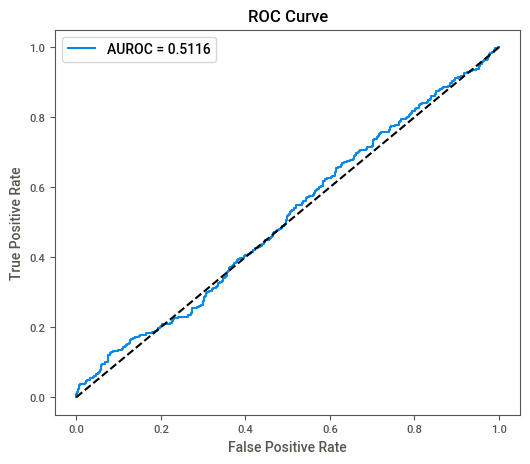

In [318]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score, roc_curve

# === Evaluation ===
model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
        preds = (probs > threshold).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

# === Confusion Matrix ===
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# === Precision, Recall, F1 ===
precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='binary')
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# === AUROC and ROC Curve ===
auc_score = roc_auc_score(all_targets, all_probs)
print(f"AUROC: {auc_score:.4f}")
print(cm)
fpr, tpr, _ = roc_curve(all_targets, all_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUROC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [319]:
%pip install xgboost

     -------------------------------------- 150.0/150.0 MB 8.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[I 2025-06-25 16:57:11,068] A new study created in memory with name: no-name-e900b460-0951-4886-89b5-21d1d34abfc3


scale_pos_weight: 4.85


[I 2025-06-25 16:57:13,117] Trial 0 finished with value: 0.4831315658671789 and parameters: {'n_estimators': 437, 'max_depth': 12, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}. Best is trial 0 with value: 0.4831315658671789.
[I 2025-06-25 16:57:13,284] Trial 1 finished with value: 0.5058575749151228 and parameters: {'n_estimators': 240, 'max_depth': 3, 'learning_rate': 0.13983740016490973, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 1 with value: 0.5058575749151228.
[I 2025-06-25 16:57:13,964] Trial 2 finished with value: 0.4824121111026866 and parameters: {'n_estimators': 118, 'max_depth': 12, 'learning_rate': 0.11536162338241392, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503}. Best is trial 1 with value: 0.5058575749151228.
[I 2025-06-25 16:57:14,369] Trial 3 finished with value: 0.5026073916816203 and parameters: {'n_estimators': 265, 'max_depth': 6

Best trial: FrozenTrial(number=40, state=1, values=[0.5742099898063201], datetime_start=datetime.datetime(2025, 6, 25, 16, 58, 6, 881465), datetime_complete=datetime.datetime(2025, 6, 25, 16, 58, 7, 438453), params={'n_estimators': 678, 'max_depth': 3, 'learning_rate': 0.0025140500710472777, 'subsample': 0.9492770942635396, 'colsample_bytree': 0.803214529829795}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None)}, trial_id=40, value=None)

Classification Report:
              precision    recall  f1-score   support

           0     0.8805    0.6579    0.7531      1815
           1     0.2099    0.5046   

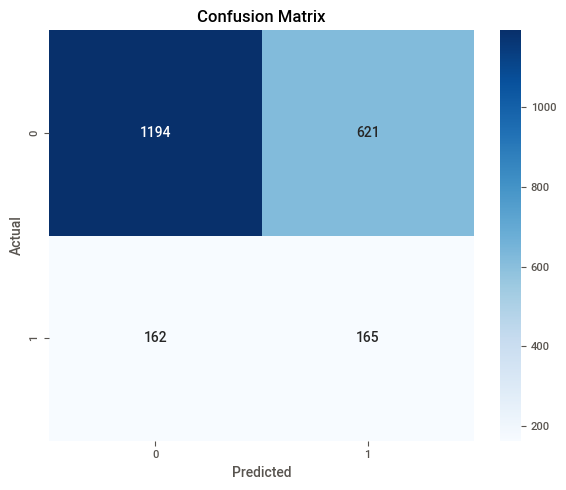

In [325]:
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")



# === 3. Feature Scaling ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === 4. Handle Class Imbalance ===
# scale_pos_weight = (negative / positive)
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# === 5. Optuna Objective ===
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'use_label_encoder': False,
        'random_state': 42
    }

    model = XGBClassifier(**params)
    model.fit(X_train_scaled, y_train)
    preds = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, preds)
    return auc

# === 6. Run Optimization ===
sampler = optuna.samplers.RandomSampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50)
print("Best trial:", study.best_trial)

# === 7. Train Final Model with Best Params ===
best_params = study.best_params
best_params['scale_pos_weight'] = scale_pos_weight
best_params['objective'] = 'binary:logistic'
best_params['eval_metric'] = 'auc'
best_params['use_label_encoder'] = False
best_params['random_state'] = 42

final_model = XGBClassifier(**best_params)
final_model.fit(X_train_scaled, y_train)

# === 8. Predictions & Metrics ===
y_pred = final_model.predict(X_test_scaled)
y_probs = final_model.predict_proba(X_test_scaled)[:, 1]

conf_mat = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probs)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))
print(f"AUROC: {auc:.4f}")

# === 9. Plot Confusion Matrix ===
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


[I 2025-06-25 16:58:55,960] A new study created in memory with name: no-name-9feabba9-6045-443d-9531-631fc7992d76
[I 2025-06-25 16:58:57,388] Trial 0 finished with value: 0.49485177041473954 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}. Best is trial 0 with value: 0.49485177041473954.
[I 2025-06-25 16:58:57,527] Trial 1 finished with value: 0.512956082931062 and parameters: {'n_estimators': 162, 'max_depth': 3, 'learning_rate': 0.13983740016490973, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 1 with value: 0.512956082931062.
[I 2025-06-25 16:58:58,132] Trial 2 finished with value: 0.5091380864525151 and parameters: {'n_estimators': 108, 'max_depth': 10, 'learning_rate': 0.11536162338241392, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503}. Best is trial 1 with value: 0.512956082931062.
[I 2025-06-25 1

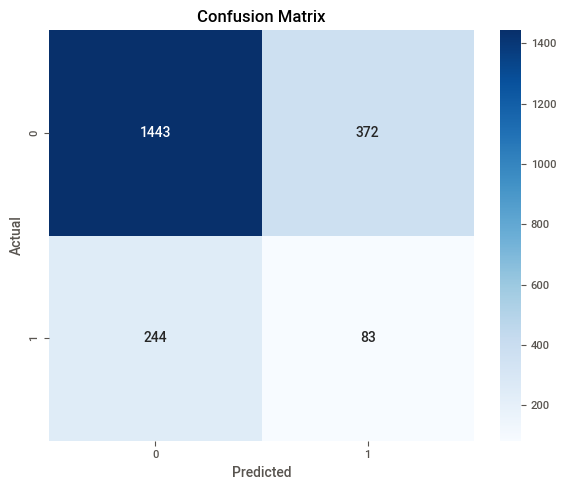

({'0': {'precision': 0.8553645524599881,
   'recall': 0.7950413223140496,
   'f1-score': 0.8241005139920046,
   'support': 1815.0},
  '1': {'precision': 0.1824175824175824,
   'recall': 0.25382262996941896,
   'f1-score': 0.21227621483375958,
   'support': 327.0},
  'accuracy': 0.7124183006535948,
  'macro avg': {'precision': 0.5188910674387852,
   'recall': 0.5244319761417342,
   'f1-score': 0.5181883644128821,
   'support': 2142.0},
  'weighted avg': {'precision': 0.7526317517112174,
   'recall': 0.7124183006535948,
   'f1-score': 0.7306987652409559,
   'support': 2142.0}},
 np.float64(0.576434907877777))

In [326]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import optuna
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# 3. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 5. Compute scale_pos_weight for XGBoost (optional if using SMOTE)
# Use scale_pos_weight = 1 since data is now balanced

# 6. Optuna objective function
def objective(trial):
    try:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'use_label_encoder': False,
            'random_state': 42
        }

        model = XGBClassifier(**params)
        model.fit(X_train_scaled, y_train_res)

        preds = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, preds)
        return auc

    except Exception as e:
        return 0.0

# 7. Run optimization with safe sampler
sampler = optuna.samplers.RandomSampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=30)

# 8. Train final model
best_params = study.best_params
best_params.update({'objective': 'binary:logistic', 'eval_metric': 'auc',
                    'use_label_encoder': False, 'random_state': 42})
final_model = XGBClassifier(**best_params)
final_model.fit(X_train_scaled, y_train_res)

# 9. Evaluate on test set
y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
auroc = roc_auc_score(y_test, y_proba)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

report, auroc


In [327]:
%pip install lightgbm

     ---------------------------------------- 1.5/1.5 MB 2.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[I 2025-06-25 17:11:31,680] A new study created in memory with name: no-name-c734cb50-9dd9-4c66-90b0-aa3f4172b07f


[0]	validation_0-auc:0.47538
[1]	validation_0-auc:0.47603
[2]	validation_0-auc:0.47769
[3]	validation_0-auc:0.48740
[4]	validation_0-auc:0.49703
[5]	validation_0-auc:0.49708
[6]	validation_0-auc:0.49550
[7]	validation_0-auc:0.49327
[8]	validation_0-auc:0.49128
[9]	validation_0-auc:0.49640
[10]	validation_0-auc:0.50152
[11]	validation_0-auc:0.49785
[12]	validation_0-auc:0.50268
[13]	validation_0-auc:0.50330
[14]	validation_0-auc:0.50456
[15]	validation_0-auc:0.50446
[16]	validation_0-auc:0.50283
[17]	validation_0-auc:0.50813
[18]	validation_0-auc:0.50934
[19]	validation_0-auc:0.50675
[20]	validation_0-auc:0.50803
[21]	validation_0-auc:0.50848
[22]	validation_0-auc:0.51035
[23]	validation_0-auc:0.51579
[24]	validation_0-auc:0.51414
[25]	validation_0-auc:0.51396
[26]	validation_0-auc:0.51126
[27]	validation_0-auc:0.50869
[28]	validation_0-auc:0.50651
[29]	validation_0-auc:0.50197
[30]	validation_0-auc:0.50086
[31]	validation_0-auc:0.50138
[32]	validation_0-auc:0.50119
[33]	validation_0-au

[I 2025-06-25 17:11:33,285] Trial 0 finished with value: 0.5025736935661873 and parameters: {'n_estimators': 250, 'learning_rate': 0.22648248189516848, 'max_depth': 10, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}. Best is trial 0 with value: 0.5025736935661873.


[0]	validation_0-auc:0.46146
[1]	validation_0-auc:0.49142
[2]	validation_0-auc:0.48351
[3]	validation_0-auc:0.49351
[4]	validation_0-auc:0.49478
[5]	validation_0-auc:0.49552
[6]	validation_0-auc:0.49815
[7]	validation_0-auc:0.50043
[8]	validation_0-auc:0.49997
[9]	validation_0-auc:0.49512
[10]	validation_0-auc:0.49234
[11]	validation_0-auc:0.49254
[12]	validation_0-auc:0.49211
[13]	validation_0-auc:0.49085
[14]	validation_0-auc:0.49210
[15]	validation_0-auc:0.49314
[16]	validation_0-auc:0.49282
[17]	validation_0-auc:0.48970
[18]	validation_0-auc:0.49043
[19]	validation_0-auc:0.48862
[20]	validation_0-auc:0.49201
[21]	validation_0-auc:0.49116
[22]	validation_0-auc:0.49093
[23]	validation_0-auc:0.49434
[24]	validation_0-auc:0.49339
[25]	validation_0-auc:0.49279
[26]	validation_0-auc:0.49541
[27]	validation_0-auc:0.49274
[28]	validation_0-auc:0.49231
[29]	validation_0-auc:0.49387
[30]	validation_0-auc:0.49253
[31]	validation_0-auc:0.49372
[32]	validation_0-auc:0.49126
[33]	validation_0-au

[I 2025-06-25 17:11:35,919] Trial 1 finished with value: 0.4879428142981104 and parameters: {'n_estimators': 162, 'learning_rate': 0.0013927723945289009, 'max_depth': 11, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 0 with value: 0.5025736935661873.


...

[LightGBM] [Info] Number of positive: 3340, number of negative: 3340
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 6680, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[I 2025-06-25 17:12:49,737] Trial 28 finished with value: 0.5168254690356442 and parameters: {'n_estimators': 112, 'learning_rate': 0.0012374167549216975, 'max_depth': 11, 'subsample': 0.6800953207056315, 'colsample_bytree': 0.5635302563259423}. Best is trial 10 with value: 0.5805149072038146.


[LightGBM] [Info] Number of positive: 3340, number of negative: 3340
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 6680, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

[I 2025-06-25 17:12:50,422] Trial 29 finished with value: 0.49812722723481695 and parameters: {'n_estimators': 309, 'learning_rate': 0.08079182088739334, 'max_depth': 5, 'subsample': 0.8114452379095001, 'colsample_bytree': 0.542673732496884}. Best is trial 10 with value: 0.5805149072038146.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

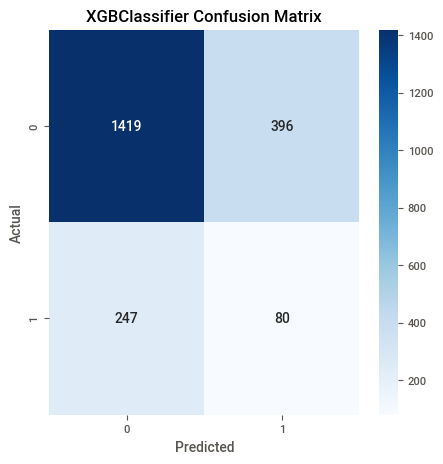

=== XGBClassifier Metrics ===
Precision: 0.1681
Recall:    0.2446
F1-score:  0.1993
AUROC:     0.5737

[LightGBM] [Info] Number of positive: 3340, number of negative: 3340
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000232 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 6680, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

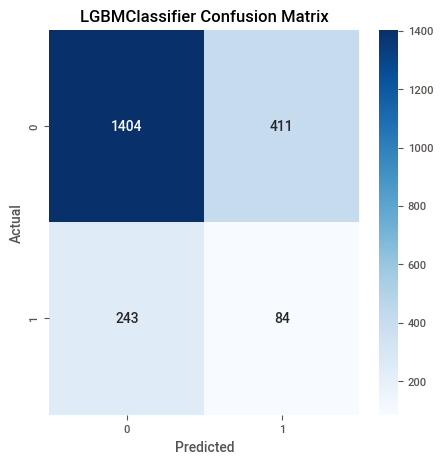

=== LGBMClassifier Metrics ===
Precision: 0.1697
Recall:    0.2569
F1-score:  0.2044
AUROC:     0.5805



In [331]:
# Install required packages if you haven't already:
# pip install optuna xgboost lightgbm imbalanced-learn matplotlib seaborn scikit-learn

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import lightgbm as lgb



# === 2. Apply SMOTE to balance training data ===
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# === 3. Optuna objective for both XGB and LGBM ===
def objective(trial, model_type='xgb'):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42
    }
    if model_type == 'lgb':
        params.update({'objective': 'binary', 'metric': 'auc'})
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train_scaled, y_train_res,
                  eval_set=[(X_test_scaled, y_test)])
    else:
        params.update({'objective': 'binary:logistic', 'eval_metric': 'auc', 'use_label_encoder': False})
        model = XGBClassifier(**params)
        model.fit(X_train_scaled, y_train_res,
                  eval_set=[(X_test_scaled, y_test)])
    proba = model.predict_proba(X_test_scaled)[:, 1]
    return roc_auc_score(y_test, proba)

# === 4. Run Optuna studies ===
sampler = optuna.samplers.RandomSampler(seed=42)

study_xgb = optuna.create_study(direction='maximize', sampler=sampler)
study_xgb.optimize(lambda t: objective(t, 'xgb'), n_trials=30)
print("XGB best AUC:", study_xgb.best_value, "params:", study_xgb.best_params)

study_lgb = optuna.create_study(direction='maximize', sampler=sampler)
study_lgb.optimize(lambda t: objective(t, 'lgb'), n_trials=30)
print("LGBM best AUC:", study_lgb.best_value, "params:", study_lgb.best_params)

# === 5. Train final models ===
def train_and_eval(model_cls, best_params):
    best_params = best_params.copy()
    best_params.update({'random_state': 42})
    model = model_cls(**best_params)

    model.fit(X_train_scaled, y_train_res)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)

    # Plot confusion matrix
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_cls.__name__} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f"=== {model_cls.__name__} Metrics ===")
    print(f"Precision: {report['1']['precision']:.4f}")
    print(f"Recall:    {report['1']['recall']:.4f}")
    print(f"F1-score:  {report['1']['f1-score']:.4f}")
    print(f"AUROC:     {auc:.4f}\n")

# Prepare parameter dicts
xgb_params = study_xgb.best_params.copy()
xgb_params.update({'objective': 'binary:logistic', 'eval_metric': 'auc', 'use_label_encoder': False})
train_and_eval(XGBClassifier, xgb_params)

lgb_params = study_lgb.best_params.copy()
lgb_params.update({'objective': 'binary', 'metric': 'auc'})
train_and_eval(lgb.LGBMClassifier, lgb_params)
